In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

df=pd.read_csv("indian_cricket_weather_dataset_100000.csv")
df

,city,temperature_c,humidity_percent,wind_speed_kmh,rainfall_mm,cloud_cover_percent,condition,play_cricket
0,Hyderabad,26.6,82,9.7,11.1,92,Rainy,No
1,Pune,36.7,50,6.9,2.7,78,Overcast,No
2,Mumbai,16.8,85,20.9,0.0,49,Cloudy,No
3,Mumbai,23.3,32,10.1,1.4,56,Cloudy,Yes
4,Ahmedabad,36.3,69,11.0,3.4,71,Cloudy,No
...,...,...,...,...,...,...,...,...
99995,Bengaluru,32.1,38,7.0,0.0,79,Overcast,Yes
99996,Kolkata,37.1,92,0.8,1.2,42,Cloudy,No
99997,Jaipur,42.6,91,5.9,2.4,65,Cloudy,No
99998,Kolkata,29.5,84,14.4,6.2,80,Rainy,No


In [3]:
df=df.drop(["city","rainfall_mm","cloud_cover_percent"],axis=1)

In [4]:
df

,temperature_c,humidity_percent,wind_speed_kmh,condition,play_cricket
0,26.6,82,9.7,Rainy,No
1,36.7,50,6.9,Overcast,No
2,16.8,85,20.9,Cloudy,No
3,23.3,32,10.1,Cloudy,Yes
4,36.3,69,11.0,Cloudy,No
...,...,...,...,...,...
99995,32.1,38,7.0,Overcast,Yes
99996,37.1,92,0.8,Cloudy,No
99997,42.6,91,5.9,Cloudy,No
99998,29.5,84,14.4,Rainy,No


In [6]:
df.columns=["temp","humidity","wind_speed","condition","play"]

In [7]:
df

,temp,humidity,wind_speed,condition,play
0,26.6,82,9.7,Rainy,No
1,36.7,50,6.9,Overcast,No
2,16.8,85,20.9,Cloudy,No
3,23.3,32,10.1,Cloudy,Yes
4,36.3,69,11.0,Cloudy,No
...,...,...,...,...,...
99995,32.1,38,7.0,Overcast,Yes
99996,37.1,92,0.8,Cloudy,No
99997,42.6,91,5.9,Cloudy,No
99998,29.5,84,14.4,Rainy,No


In [8]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df["play"]=le.fit_transform(df["play"])

In [9]:
df

,temp,humidity,wind_speed,condition,play
0,26.6,82,9.7,Rainy,0
1,36.7,50,6.9,Overcast,0
2,16.8,85,20.9,Cloudy,0
3,23.3,32,10.1,Cloudy,1
4,36.3,69,11.0,Cloudy,0
...,...,...,...,...,...
99995,32.1,38,7.0,Overcast,1
99996,37.1,92,0.8,Cloudy,0
99997,42.6,91,5.9,Cloudy,0
99998,29.5,84,14.4,Rainy,0


In [26]:
df["condition"].value_counts()

df["condition"]=le.fit_transform(df["condition"])
df

from sklearn.preprocessing import OneHotEncoder
ohe=OneHotEncoder(handle_unknown="ignore")

x1=ohe.fit_transform(df[["condition"]])

x1=pd.DataFrame(x1.toarray())
x1

,0,1,2,3
0,0.0,0.0,1.0,0.0
1,0.0,1.0,0.0,0.0
2,1.0,0.0,0.0,0.0
3,1.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0
...,...,...,...,...
99995,0.0,1.0,0.0,0.0
99996,1.0,0.0,0.0,0.0
99997,1.0,0.0,0.0,0.0
99998,0.0,0.0,1.0,0.0


In [28]:
df=pd.concat([df,x1],axis=1)

In [29]:
df

,temp,humidity,wind_speed,condition,play,0,1,2,3
0,26.6,82,9.7,2,0,0.0,0.0,1.0,0.0
1,36.7,50,6.9,1,0,0.0,1.0,0.0,0.0
2,16.8,85,20.9,0,0,1.0,0.0,0.0,0.0
3,23.3,32,10.1,0,1,1.0,0.0,0.0,0.0
4,36.3,69,11.0,0,0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
99995,32.1,38,7.0,1,1,0.0,1.0,0.0,0.0
99996,37.1,92,0.8,0,0,1.0,0.0,0.0,0.0
99997,42.6,91,5.9,0,0,1.0,0.0,0.0,0.0
99998,29.5,84,14.4,2,0,0.0,0.0,1.0,0.0


In [31]:
df.columns=['temp', 'humidity', 'wind_speed', 'condition', 'play', 0, 1, 2,"remove"]

In [34]:
df=df.drop(["condition","remove"],axis=1)

In [35]:
df

,temp,humidity,wind_speed,play,0,1,2
0,26.6,82,9.7,0,0.0,0.0,1.0
1,36.7,50,6.9,0,0.0,1.0,0.0
2,16.8,85,20.9,0,1.0,0.0,0.0
3,23.3,32,10.1,1,1.0,0.0,0.0
4,36.3,69,11.0,0,1.0,0.0,0.0
...,...,...,...,...,...,...,...
99995,32.1,38,7.0,1,0.0,1.0,0.0
99996,37.1,92,0.8,0,1.0,0.0,0.0
99997,42.6,91,5.9,0,1.0,0.0,0.0
99998,29.5,84,14.4,0,0.0,0.0,1.0


In [36]:
x=df[["temp","humidity","wind_speed",0,1,2]]
x
y=df["play"]
y


0        0
1        0
2        0
3        1
4        0
        ..
99995    1
99996    0
99997    0
99998    0
99999    0
Name: play, Length: 100000, dtype: int64

In [37]:
x

,temp,humidity,wind_speed,0,1,2
0,26.6,82,9.7,0.0,0.0,1.0
1,36.7,50,6.9,0.0,1.0,0.0
2,16.8,85,20.9,1.0,0.0,0.0
3,23.3,32,10.1,1.0,0.0,0.0
4,36.3,69,11.0,1.0,0.0,0.0
...,...,...,...,...,...,...
99995,32.1,38,7.0,0.0,1.0,0.0
99996,37.1,92,0.8,1.0,0.0,0.0
99997,42.6,91,5.9,1.0,0.0,0.0
99998,29.5,84,14.4,0.0,0.0,1.0


In [42]:
x.columns=["temp","humidity","wind_speed","cloudy","overcast","rainy"]

In [43]:
x

,temp,humidity,wind_speed,cloudy,overcast,rainy
0,26.6,82,9.7,0.0,0.0,1.0
1,36.7,50,6.9,0.0,1.0,0.0
2,16.8,85,20.9,1.0,0.0,0.0
3,23.3,32,10.1,1.0,0.0,0.0
4,36.3,69,11.0,1.0,0.0,0.0
...,...,...,...,...,...,...
99995,32.1,38,7.0,0.0,1.0,0.0
99996,37.1,92,0.8,1.0,0.0,0.0
99997,42.6,91,5.9,1.0,0.0,0.0
99998,29.5,84,14.4,0.0,0.0,1.0


In [44]:
y

0        0
1        0
2        0
3        1
4        0
        ..
99995    1
99996    0
99997    0
99998    0
99999    0
Name: play, Length: 100000, dtype: int64

In [ ]:
from sklearn.model_selection import train_test_split

xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=42)



75721    0
80184    1
19864    0
76699    0
92991    1
        ..
32595    1
29313    1
37862    1
53421    1
42410    1
Name: play, Length: 20000, dtype: int64

In [49]:
from sklearn.naive_bayes import GaussianNB
model=GaussianNB()

model.fit(xtrain,ytrain)

,priors,None
,var_smoothing,1e-09


In [50]:
model.score(xtest,ytest)

0.60855

<Axes: >

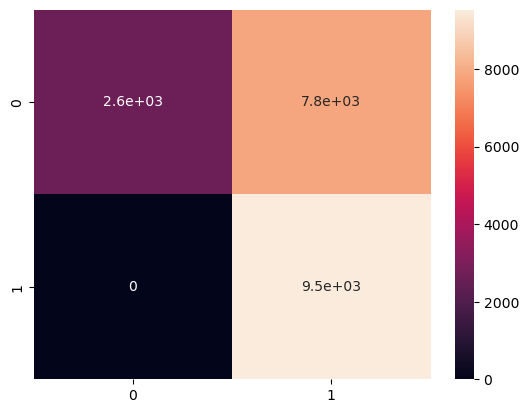

In [52]:
from sklearn.metrics import confusion_matrix

cm=confusion_matrix(ytest,model.predict(xtest))

sns.heatmap(cm,annot=True)




In [53]:
df["play"].value_counts()

play
0    52441
1    47559
Name: count, dtype: int64

In [54]:
import joblib
joblib.dump(model,"model.pkl")

joblib.dump(le,"labelencode.pkl")

['labelencode.pkl']

In [55]:
xtrain

,temp,humidity,wind_speed,cloudy,overcast,rainy
75220,35.0,84,13.3,0.0,1.0,0.0
48955,34.1,91,21.9,0.0,0.0,0.0
44966,29.9,89,6.1,0.0,0.0,1.0
13568,20.5,86,22.5,0.0,0.0,0.0
92727,27.9,92,15.0,1.0,0.0,0.0
...,...,...,...,...,...,...
6265,39.3,51,10.3,0.0,0.0,1.0
54886,30.5,58,10.0,0.0,0.0,0.0
76820,26.5,84,20.9,0.0,1.0,0.0
860,37.3,41,15.9,0.0,0.0,1.0
